# Raw Data

In [ ]:
import pandas as pd

# Hiển thị toàn bộ nội dung của mỗi cell
pd.set_option('display.max_colwidth', None)

# Hiển thị tất cả cột
pd.set_option('display.max_columns', None)

# Tăng chiều rộng hiển thị
pd.set_option('display.width', None)

# Hiển thị toàn bộ chiều rộng DataFrame
pd.set_option('display.expand_frame_repr', False)

In [3]:
df = pd.read_csv("data/00-topcv_raw.csv")

In [4]:
import pandas as pd
import numpy as np
import re

def thong_ke_missing_data(df):
    """
    Hàm thống kê dữ liệu thiếu dựa trên các điều kiện đặc thù:
    - Salary: Không có số = Missing
    - Skills: [] hoặc '[]' = Missing
    - Các cột khác: NaN hoặc chuỗi rỗng = Missing
    """
    df_temp = df.copy()
    
    # 1. Hàm kiểm tra salary (phải chứa ít nhất 1 chữ số)
    def check_salary_missing(val):
        if pd.isna(val): return True
        return not bool(re.search(r'\d', str(val)))
        
    # 2. Hàm kiểm tra mảng kỹ năng (list rỗng hoặc string '[]')
    def check_empty_array(val):
        if isinstance(val, list):
            return len(val) == 0
        if isinstance(val, str):
            return val.strip() in ['[]', "['']", '[""]', '']
        return pd.isna(val)

    # 3. Hàm kiểm tra các cột văn bản thông thường (NaN, rỗng, hoặc chỉ có khoảng trắng)
    def check_general_missing(val):
        if pd.isna(val): return True
        if isinstance(val, str) and val.strip() == '': return True
        return False

    # Duyệt qua từng cột trong DataFrame của bạn
    for col in df_temp.columns:
        if col == 'salary':
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_salary_missing(x) else x)
        elif col in ['required_skills', 'preferred_skills']:
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_empty_array(x) else x)
        else:
            # Áp dụng cho job_title, company, location, experience, etc.
            df_temp[col] = df_temp[col].apply(lambda x: np.nan if check_general_missing(x) else x)
            
    # Tính toán con số cuối cùng
    total_rows = len(df_temp)
    missing_counts = df_temp.isnull().sum()
    missing_percentages = (missing_counts / total_rows) * 100
    
    # Tạo bảng kết quả
    ket_qua = pd.DataFrame({
        'Số lượng thiếu': missing_counts,
        'Tỷ lệ (%)': missing_percentages.round(2)
    })
    
    # Sắp xếp theo tỷ lệ giảm dần và chỉ hiện các cột có thiếu dữ liệu
    ket_qua = ket_qua[ket_qua['Số lượng thiếu'] > 0].sort_values(by='Tỷ lệ (%)', ascending=False)
    
    return ket_qua

stats = thong_ke_missing_data(df)
print(stats)

                  Số lượng thiếu  Tỷ lệ (%)
preferred_skills            2988      68.16
salary                      1890      43.11
required_skills             1785      40.72
industry                     281       6.41
employment_type              276       6.30
experience                   276       6.30
company                      276       6.30
education                    276       6.30
job_description              276       6.30
level                        276       6.30
requirement                  276       6.30
location                       8       0.18


In [5]:
df.shape

(4384, 15)

# Xử lý job title

In [9]:
import pandas as pd
df = pd.read_csv("data/01-topcv_standardize_jobtitle.csv")
# df.head(1)

In [11]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =========================
# TITLE STATS
# =========================
title_counts = df['standardized_title'].value_counts()

title_percentages = (
    df['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

# =========================
# SAMPLE DESCRIPTION
# ONLY FOR COUNT = 1
# =========================
single_titles = set(
    job_title_stats[
        job_title_stats['count'] == 1
    ].index
)

sample_descriptions = (
    df[
        df['standardized_title'].isin(single_titles)
    ]
    .groupby('standardized_title')['job_description']
    .first()
)

# =========================
# MERGE
# =========================
job_title_stats['sample_description'] = (
    sample_descriptions
)

job_title_stats = (
    job_title_stats
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# =========================
# SAVE
# =========================
job_title_stats.to_csv(
    "data/job_title_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats.head())

  standardized_title  count  percentage sample_description
0   Graphic Designer    771       21.57                NaN
1  Backend Developer    225        6.29                NaN
2   Business Analyst    214        5.99                NaN
3         IT Support    155        4.34                NaN
4        QA Engineer    154        4.31                NaN


In [13]:
# In sample jobs có standardized_title == "designer"

samples = df[
    df['standardized_title']
    .str.strip()
    .str.lower()
    .eq('customer success')
][[
    'job_title',
    'standardized_title',
    'job_description'
]]

# random sample reproducible
samples = samples.sample(
    n=min(5, len(samples)),
    random_state=42
)

for i, row in samples.iterrows():
    print("=" * 100)

    print("JOB TITLE:")
    print(row['job_title'])

    print("\nSTANDARDIZED TITLE:")
    print(row['standardized_title'])

    print("\nJOB DESCRIPTION:")
    print(row['job_description'][:3000])

    print("\n")

JOB TITLE:
Chuyên Viên Chăm Sóc Khách Hàng & Đào Tạo ( Customer Success Specialist)

STANDARDIZED TITLE:
Customer Success

JOB DESCRIPTION:
Tiếp nhận bàn giao & Đào tạo (Sau Go-live) - Nhận bàn giao chi tiết từ Implementation Specialist: cấu hình đã triển khai, luồng nghiệp vụ, đặc thù khách hàng, đầu mối liên hệ từng phòng ban. - Tổ chức đào tạo theo vai trò: Admin hệ thống (được hướng dẫn cấu hình cơ bản), Quản lý (dashboard, báo cáo), Nhân viên (thao tác hàng ngày). - Soạn tài liệu hướng dẫn sử dụng bằng tiếng Việt, có hình ảnh minh họa, theo từng luồng nghiệp vụ cụ thể của khách hàng. - Quay video hướng dẫn ngắn (2–5 phút) cho các thao tác phổ biến: tạo đơn hàng, tra cứu tồn kho, xử lý ticket,... Theo dõi sức khỏe khách hàng (Ongoing) - Theo dõi mức độ sử dụng thực tế: số lượng user đăng nhập, số bản ghi tạo mới, các module được dùng/không dùng. - Chủ động liên hệ khách hàng định kỳ (2 tuần/lần trong tháng đầu, sau đó hàng tháng): thu thập phản hồi, giải đáp thắc mắc. - Phát hiện s

In [14]:
import pandas as pd
import re

# =========================
# COPY DATAFRAME
# =========================
df_filtered = df.copy()

# =========================
# NORMALIZE TITLE
# =========================
title_series = (
    df_filtered["standardized_title"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# =========================
# EXACT TITLES TO DROP
# =========================
exact_drop_titles = {
    "business architect",
    "sales consultant",
    "it procurement",
    "product marketer",
    "monetization specialist",
    "ad monetization specialist",
    "cad designer",
    "media designer",
    "photo editor",
    "web designer",
    "motion graphics designer",
    "digital artist",
    "illustrator",
    "content moderator",
    "game operator",
    "data operator",
    "maintenance technician",
    "electrical engineer",
    "technical support",
    "designer",
    "Game Operations",
    "User Acquisition Specialist",
    "IT Communicator",
    "Product Operations",
    "Project Coordinator",
    "customer success",
    "IT Compliance Specialist",
    "system analyst",
}

# =========================
# KEYWORDS TO DROP
# safer keywords
# =========================
drop_keywords = [
    "graphic",
    "artist",
    "3d", "2d",
    "multimedia",
    "illustrator"
    "media",
    "business development",
    "video editor",
    "animator",
    "marketing",
    "data entry",
    "content",
    "cnc",
    "seo",
    "trainer",
    "writer",
]

# =========================
# BUILD KEYWORD REGEX
# =========================
escaped_keywords = [
    re.escape(keyword)
    for keyword in drop_keywords
]

keyword_pattern = "|".join(escaped_keywords)

# =========================
# DROP CONDITIONS
# =========================

# keyword match
mask_keywords = title_series.str.contains(
    keyword_pattern,
    case=False,
    na=False,
    regex=True
)

# exact title match
mask_exact_titles = title_series.isin(
    exact_drop_titles
)

# sales/account rules
# avoid dropping:
# - presales engineer
# - pre-sales engineer
# - sales engineer
# - solution engineer
# - technical account manager

mask_sales = (
    title_series.str.contains(
        r'\bsales\b',
        case=False,
        na=False,
        regex=True
    )
    &
    ~title_series.str.contains(
        r'presales|pre-sales|sales engineer',
        case=False,
        na=False,
        regex=True
    )
)

mask_account_manager = (
    title_series.eq("account manager")
)

# =========================
# FINAL DROP MASK
# =========================
drop_mask = (
    mask_keywords
    | mask_exact_titles
    | mask_sales
    | mask_account_manager
)

# =========================
# FILTER
# =========================
df_filtered = df_filtered[
    ~drop_mask
].copy()

# =========================
# SAVE CSV
# =========================
df_filtered.to_csv(
    "data/02-topcv_job_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================
# SUMMARY
# =========================
print(f"Original rows: {len(df):,}")
print(f"Filtered rows: {len(df_filtered):,}")
print(f"Dropped rows: {len(df) - len(df_filtered):,}")

print("\nSaved to:")
print("01-topcv_job_filtered.csv")

Original rows: 4,384
Filtered rows: 3,215
Dropped rows: 1,169

Saved to:
01-topcv_job_filtered.csv


In [15]:
import re

# =========================
# TOKENIZER
# =========================
def tokenize(text):
    return re.findall(
        r'\b[a-zA-Z0-9]+\b',
        str(text).lower()
    )

# =========================
# TITLE MAPPING
# =========================
def map_standardized_title(title):

    t = str(title).strip().lower()
    tokens = tokenize(t)

    # ---------------------------------
    # QA Engineer
    # ---------------------------------
    if (
        "tester" in tokens
        or "qa" in tokens
        or "quality assurance" in t
    ):
        return "QA Engineer"

    # ---------------------------------
    # UI/UX Designer
    # ---------------------------------
    if (
        "ui/ux" in t
        or "ux/ui" in t
        or (
            "ui" in tokens
            and "ux" in tokens
        )
        or (
            "ui" in tokens
            and "designer" in tokens
        )
        or (
            "ux" in tokens
            and "designer" in tokens
        )
    ):
        return "UI/UX Designer"

    # ---------------------------------
    # Fullstack Developer
    # ---------------------------------
    if (
        "fullstack" in tokens
        or (
            "full" in tokens
            and "stack" in tokens
        )
    ):
        return "Fullstack Developer"

    # ---------------------------------
    # Software Engineer
    # ---------------------------------
    if t in {
        "software developer",
    }:
        return "Software Engineer"

    # ---------------------------------
    # Solution Architect
    # ---------------------------------
    if t in {
        "solutions architect", "it architect"
    }:
        return "Solution Architect"

    # ---------------------------------
    # IT Support
    # ---------------------------------
    if t in {
        "application support",
        "it technician",
    }:
        return "IT Support"

    # ---------------------------------
    # Solution Engineer
    # ---------------------------------
    if t in {
        "solutions engineer",
    }:
        return "Solution Engineer"

    # ---------------------------------
    # Embedded Engineer
    # ---------------------------------
    if (
        t in {
            "iot engineer",
            "embedded developer",
            "firmware engineer",
            "FPGA Engineer",
        }
        or "embedded" in tokens
    ):
        return "Embedded Engineer"

    # ---------------------------------
    # Project Manager
    # ---------------------------------
    if t in {
        "it manager",
        "project managment office",
        "project management office",
        "project management officer",
    }:
        return "Project Manager"

    # ---------------------------------
    # Game Developer
    # ---------------------------------
    if t in {
        "unity developer",
    }:
        return "Game Developer"

    # ---------------------------------
    # AI Engineer
    # ---------------------------------
    if t in {
        "computer vision engineer",
        "machine vision engineer",
        "voice engineer",
        "nlp engineer"
    }:
        return "AI Engineer"

    # ---------------------------------
    # Machine Learning Engineer
    # ---------------------------------
    if t in {
        "ml engineer",
    }:
        return "Machine Learning Engineer"

    # ---------------------------------
    # Bridge Engineer
    # ---------------------------------
    if (
        "bridge" in tokens
        or "brse" in tokens
    ):
        return "Bridge Engineer"

    # ---------------------------------
    # Presales Engineer
    # ---------------------------------
    if (
        "presales" in tokens
        or (
            "pre" in tokens
            and "sales" in tokens
        )
    ):
        return "Presales Engineer"

    # ---------------------------------
    # Mobile Developer
    # ---------------------------------
    if t in {
        "ios developer",
    }:
        return "Mobile Developer"

    # ---------------------------------
    # ERP Developer
    # ---------------------------------
    if t in {
        "odoo developer",
    }:
        return "ERP Developer"

    # default
    return title

# =========================
# APPLY MAPPING
# =========================
df_filtered["standardized_title"] = (
    df_filtered["standardized_title"]
    .apply(map_standardized_title)
)

# =========================
# SEMANTIC MERGE MAP
# =========================
semantic_merge_map = {

    # ---------------------------------
    # Systems
    # ---------------------------------
    "Systems Engineer": "System Engineer",

    # ---------------------------------
    # Low-Code
    # ---------------------------------
    "Low Code Developer": "Low-Code Developer",

    # ---------------------------------
    # AI
    # ---------------------------------
    "AI Specialist": "AI Engineer",
    "AI/ML Engineer": "AI Engineer",

    # ---------------------------------
    # Security
    # ---------------------------------
    "Cybersecurity Engineer": "Security Engineer",
    "Security Specialist": "Security Engineer",

    # ---------------------------------
    # Support
    # ---------------------------------
    "Application Support Engineer": "IT Support",
    "Product Support": "IT Support",

    # ---------------------------------
    # Project Management
    # ---------------------------------
    "IT Project Manager": "Project Manager",

    # ---------------------------------
    # Database
    # ---------------------------------
    "Database Administrator": "Database Engineer",
    "Database Developer": "Database Engineer",

    # ---------------------------------
    # Architecture
    # ---------------------------------
    "Infrastructure Architect": "Solution Architect",
    "Network Architect": "Solution Architect",

    # ---------------------------------
    # ERP
    # ---------------------------------
    "ERP Specialist": "ERP Consultant",

    # ---------------------------------
    # Implementation
    # ---------------------------------
    "Software Implementer": "Implementation Specialist",
    "Software Implementation Specialist": "Implementation Specialist",
    "Implementation Engineer": "Implementation Specialist",
    "Implementation Consultant": "Implementation Specialist",

    # ---------------------------------
    # DevOps
    # ---------------------------------
    "DevSecOps Engineer": "DevOps Engineer",

    # ---------------------------------
    # Cloud / Infra
    # ---------------------------------
    "Infrastructure Engineer": "Cloud Engineer",
    "Data Center Engineer": "Cloud Engineer",

    # ---------------------------------
    # Product
    # ---------------------------------
    "Product Owner": "Product Manager",

    # ---------------------------------
    # Data Governance
    # ---------------------------------
    "Data Governance Specialist": "Data Governance Analyst",

    # ---------------------------------
    # IT Operations
    # ---------------------------------
    "NOC Engineer": "IT Operations",

    # ---------------------------------
    # Consultant
    # ---------------------------------
    "Functional Consultant": "ERP Consultant",

    # ---------------------------------
    # Embedded
    # ---------------------------------
    "Hardware Technician": "Hardware Engineer",

    # ---------------------------------
    # QA
    # ---------------------------------
    "Quality Assurance Engineer": "QA Engineer",
}

# =========================
# APPLY SEMANTIC MERGE
# =========================
df_filtered["standardized_title"] = (
    df_filtered["standardized_title"]
    .replace(semantic_merge_map)
)

df_filtered.to_csv(
    "02-topcv_job_filtered.csv",
    index=False,
    encoding="utf-8-sig"
)

In [16]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =========================
# TITLE STATS
# =========================
title_counts = df_filtered['standardized_title'].value_counts()

title_percentages = (
    df_filtered['standardized_title']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

job_title_stats = pd.DataFrame({
    'count': title_counts,
    'percentage': title_percentages,
})

# =========================
# SAMPLE DESCRIPTION
# ONLY FOR COUNT = 1
# =========================
single_titles = set(
    job_title_stats[
        job_title_stats['count'] == 1
    ].index
)

sample_descriptions = (
    df_filtered[
        df_filtered['standardized_title'].isin(single_titles)
    ]
    .groupby('standardized_title')['job_description']
    .first()
)

# =========================
# MERGE
# =========================
job_title_stats['sample_description'] = (
    sample_descriptions
)

job_title_stats = (
    job_title_stats
    .reset_index()
    .rename(columns={'index': 'standardized_title'})
)

# =========================
# SAVE
# =========================
job_title_stats.to_csv(
    "data/job_title_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

print(job_title_stats.head())

  standardized_title  count  percentage sample_description
0        QA Engineer    237        9.85                NaN
1  Backend Developer    225        9.35                NaN
2   Business Analyst    214        8.89                NaN
3         IT Support    169        7.02                NaN
4    Project Manager    123        5.11                NaN


In [17]:
df_filtered.shape

(3215, 17)

In [34]:
import pandas as pd

salary_raw = df_filtered["salary"]

salary_str = salary_raw.astype("string").str.strip().str.lower()

thoa_thuan_values = {
    "thỏa thuận",
    "thoả thuận",
    "thoa thuan",
    "negotiable"
}

df_filtered["is_null_salary"] = salary_raw.isna()
df_filtered["is_thoa_thuan"] = salary_str.isin(thoa_thuan_values)

# gộp missing
df_filtered["is_missing_salary"] = df_filtered["is_null_salary"] | df_filtered["is_thoa_thuan"]

result = (
    df_filtered.groupby("standardized_title")
    .agg(
        total=("salary", "size"),
        missing_salary_count=("is_missing_salary", "sum"),
        missing_salary_pct=("is_missing_salary", "mean"),
    )
    .reset_index()
)

result["missing_salary_pct"] *= 100

result = result.sort_values("total", ascending=False)

result

,standardized_title,total,missing_salary_count,missing_salary_pct
72,QA Engineer,237,98,41.350211
7,Backend Developer,225,99,44.000000
10,Business Analyst,214,85,39.719626
53,IT Support,169,63,37.278107
71,Project Manager,123,78,63.414634
58,Mobile Developer,108,45,41.666667
37,Fullstack Developer,107,44,41.121495
68,Product Manager,99,43,43.434343
0,AI Engineer,87,42,48.275862
26,DevOps Engineer,65,38,58.461538


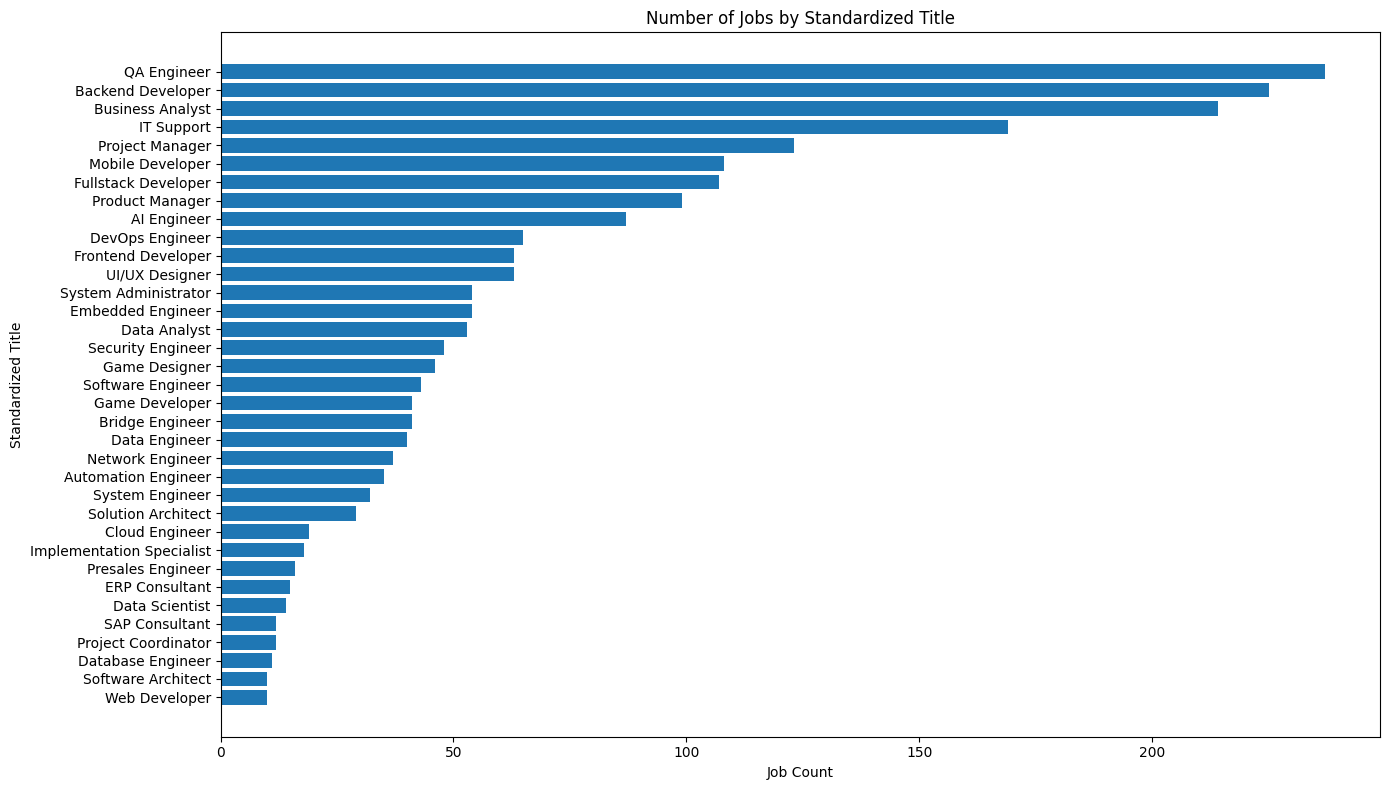

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# COUNT JOBS BY TITLE
# =========================

result = (
    df_filtered.groupby("standardized_title")
    .size()
    .reset_index(name="count")
)

# chỉ lấy title có >= 10 dòng
plot_df = result[
    result["count"] >= 10
].sort_values(
    "count",
    ascending=False
)

# =========================
# VISUALIZE
# =========================

plt.figure(figsize=(14, 8))

plt.barh(
    plot_df["standardized_title"],
    plot_df["count"]
)

plt.xlabel("Job Count")
plt.ylabel("Standardized Title")
plt.title("Number of Jobs by Standardized Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

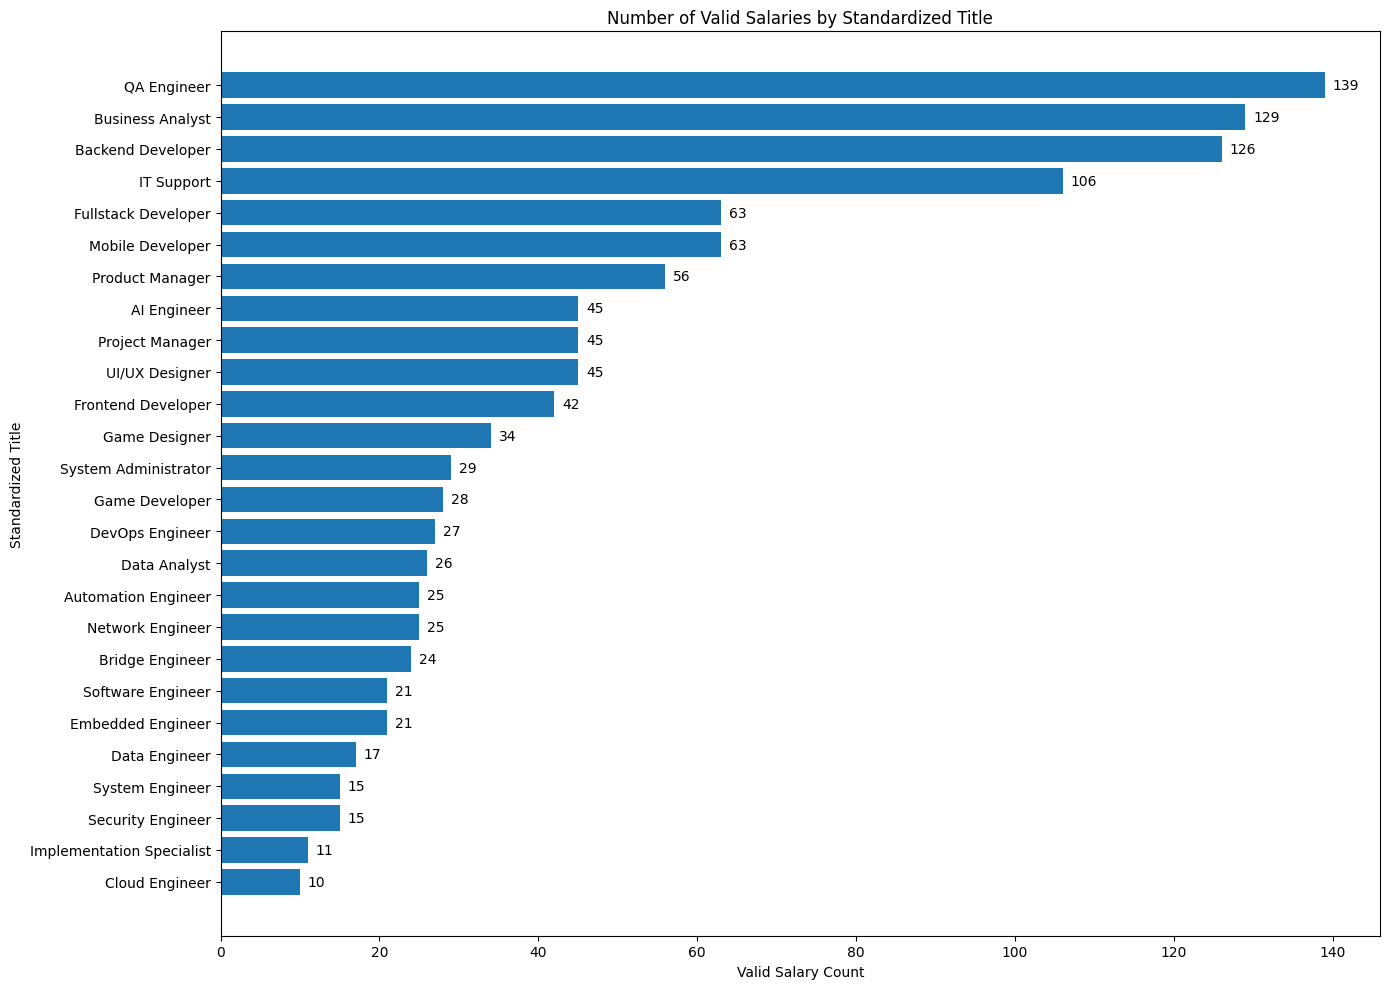

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DEFINE VALID SALARY
# =========================

salary_raw = df_filtered["salary"]

salary_str = (
    salary_raw.astype("string")
    .str.strip()
    .str.lower()
)

invalid_salary_values = {
    "thỏa thuận",
    "thoả thuận",
    "thoa thuan",
    "negotiable",
    ""
}

is_valid_salary = ~(
    salary_raw.isna()
    | salary_str.isin(invalid_salary_values)
)

# =========================
# FILTER VALID SALARY ROWS
# =========================

df_valid = df_filtered[is_valid_salary].copy()

# =========================
# COUNT VALID SALARY BY TITLE
# =========================

result = (
    df_valid.groupby("standardized_title")
    .size()
    .reset_index(name="valid_salary_count")
)

# chỉ lấy title có >= 10 salary hợp lệ
plot_df = result[
    result["valid_salary_count"] >= 10
].sort_values(
    "valid_salary_count",
    ascending=False
)

# =========================
# VISUALIZE
# =========================

plt.figure(figsize=(14, 10))

bars = plt.barh(
    plot_df["standardized_title"],
    plot_df["valid_salary_count"]
)

# hiển thị số trên bar
for i, v in enumerate(plot_df["valid_salary_count"]):
    plt.text(v + 1, i, str(v), va="center")

plt.xlabel("Valid Salary Count")
plt.ylabel("Standardized Title")
plt.title("Number of Valid Salaries by Standardized Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
import os

# 1. Lọc bỏ các dòng có is_valid_job = False
df_filtered = df_filtered[df_filtered["is_valid_job"] != False].copy()
# (Nếu cột là dạng chữ, dùng: df_filtered = df_filtered[df_filtered["is_valid_job"].astype(str).str.lower() != "false"].copy())

# 2. Drop luôn cột 'is_valid_job'
df_filtered = df_filtered.drop(columns=["is_valid_job"])

# 3. Tạo thư mục (nếu chưa có) và lưu file CSV
os.makedirs("data", exist_ok=True)
output_path = "data/02-topcv_job_filtered.csv"

df_filtered.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Đã xóa dòng, drop cột và lưu file tại: {output_path}")

Đã xóa dòng, drop cột và lưu file tại: data/02-topcv_job_filtered.csv
